In [1]:
import logging

import matplotlib.pyplot as plt
import torch

import cryosim
from cryosim.fft_tools import fft2
from cryosim.imagegenerator import ImageGenerator
from cryosim.pdbtools import PDB
from cryosim.plotting_tools import plot3d
from cryosim.potential import PotentialBuilder
from cryosim.array_utils import radial_profile_2d
from cryosim.progress import track
from cryosim.cryosparc_utils import extract_parameters_from_csfile
from cryosparc.dataset import Dataset

import mrcfile

%load_ext autoreload
%autoreload 2

In [2]:
cryosim.set_verbosity(logging.INFO)

## Required parameters

In [3]:
n = 256  # number of pixels in image
pdb_code = "6bdf"
dose_per_angstrom = 53  # e-/A^2, from EMDB Experiment tab.
num_frames = int(dose_per_angstrom)  # usually ~ 1-2 e-/A^2/frame

## Specify .cs from CryoSPARC Job that contains rotations and aberrations

In [2]:
cs_path = "/scratch/loh/joel/cryosparc_tutorial/CS-cryosparc-tutorial/J35/J35_passthrough_particles.cs"
df = Dataset.load(cs_path)
df

,uid,alignments3D/split,alignments3D/shift,alignments3D/pose,alignments3D/psize_A,alignments3D/error,alignments3D/error_min,alignments3D/resid_pow,alignments3D/slice_pow,alignments3D/image_pow,alignments3D/cross_cor,alignments3D/alpha,alignments3D/alpha_min,alignments3D/weight,alignments3D/pose_ess,alignments3D/shift_ess,alignments3D/class_posterior,alignments3D/class,alignments3D/class_ess,ctf/type,ctf/exp_group_id,ctf/accel_kv,ctf/cs_mm,ctf/amp_contrast,ctf/df1_A,ctf/df2_A,ctf/df_angle_rad,ctf/phase_shift_rad,ctf/scale,ctf/scale_const,ctf/shift_A,ctf/tilt_A,ctf/trefoil_A,ctf/tetra_A,ctf/anisomag,ctf/bfactor
0,2147589814182631695,1,[0.07031209 0.07031209],[ 1.9599892 0.8099419 -0.0455812],0.6066666841506958,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0,0.0,imported,13,300.0,2.612277030944824,0.10000000149011612,7173.31591796875,7125.98681640625,-1.4171137809753418,-0.035692330449819565,1.0,0.0,[0. 0.],[0. 0.],[0. 0.],[0. 0. 0. 0.],[0. 0. 0. 0.],0.0
1,9277788921669979650,0,[-0.07031209 0.07031209],[ 0.4228452 -1.567389 -2.5084584],0.6066666841506958,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0,0.0,imported,13,300.0,2.612277030944824,0.10000000149011612,7180.51318359375,7133.18408203125,-1.4171137809753418,-0.035692330449819565,1.0,0.0,[0. 0.],[0. 0.],[0. 0.],[0. 0. 0. 0.],[0. 0. 0. 0.],0.0
2,9100468816604705177,0,[-0.2109379 -0.07031209],[ 2.553843 -0.9214895 0.89223623],0.6066666841506958,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0,0.0,imported,13,300.0,2.612277030944824,0.10000000149011612,7159.71435546875,7112.38525390625,-1.4171137809753418,-0.035692330449819565,1.0,0.0,[0. 0.],[0. 0.],[0. 0.],[0. 0. 0. 0.],[0. 0. 0. 0.],0.0
3,8581749811742833732,0,[0.07031209 0.2109379 ],[-1.2096534 -2.1703634 -0.51541764],0.6066666841506958,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0,0.0,imported,13,300.0,2.612277030944824,0.10000000149011612,7187.71435546875,7140.38525390625,-1.4171137809753418,-0.035692330449819565,1.0,0.0,[0. 0.],[0. 0.],[0. 0.],[0. 0. 0. 0.],[0. 0. 0. 0.],0.0
4,13917039941138942153,0,[ 0.07031209 -0.07031209],[ 1.4761279 -1.279778 0.62761736],0.6066666841506958,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0,0.0,imported,4,300.0,2.6140520572662354,0.10000000149011612,4531.85009765625,4453.24267578125,0.42661067843437195,-0.028099171817302704,1.0,0.0,[0. 0.],[0. 0.],[0. 0.],[0. 0. 0. 0.],[0. 0. 0. 0.],0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5560,16239842854114389664,1,[-0.2109379 0.07031209],[ 0.8029296 -1.4060029 0.045581 ],0.6066666841506958,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0,0.0,imported,2,300.0,2.616950035095215,0.10000000149011612,7777.45654296875,7772.2041015625,0.9406300187110901,-0.02843773178756237,1.0,0.0,[0. 0.],[0. 0.],[0. 0.],[0. 0. 0. 0.],[0. 0. 0. 0.],0.0
5561,3713752084731249588,1,[-0.07031209 -0.2109379 ],[ 0.5504799 0.8099418 -1.3078281],0.6066666841506958,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0,0.0,imported,2,300.0,2.616950035095215,0.10000000149011612,7823.85693359375,7818.6044921875,0.9406300187110901,-0.02843773178756237,1.0,0.0,[0. 0.],[0. 0.],[0. 0.],[0. 0. 0. 0.],[0. 0. 0. 0.],0.0
5562,1355155552338965490,0,[-0.07031209 0.07031209],[ 0.63462967 1.4410653 -0.36114287],0.6066666841506958,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0,0.0,imported,2,300.0,2.616950035095215,0.10000000149011612,7792.65673828125,7787.404296875,0.9406300187110901,-0.02843773178756237,1.0,0.0,[0. 0.],[0. 0.],[0. 0.],[0. 0. 0. 0.],[0. 0. 0. 0.],0.0
5563,11097453170127001737,1,[0.07031209 0.2109379 ],[-2.871612 -0.7678671 0.8870795],0.6066666841506958,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0,0.0,imported,2,300.0,2.616950035095215,0.10000000149011612,7743.05712890625,7737.8046875,0.9406300187110901,-0.02843773178756237,1.0,0.0,[0. 0.],[0. 0.],[0. 0.],[0. 0. 0. 0.],[0. 0. 0. 0.],0.0


In [3]:
(
    energy_kev,
    pixel_size,
    alpha,
    rotations,
    translations_A,
    ctf_params,
    scale,
    anisomag,
    indices,
) = extract_parameters_from_csfile(cs_path)

## Generate particle scattering potential

In [6]:
# fetch pdb file
assembly = True  # True: fetches assembly. False: fetches subunit. int: fetches specific assembly #int
pdb = PDB(pdb_code, assembly=True, savefolder="../pdb-data/")
# pdb = PDB(
#     "/scratch/loh/joel/czii/russo-scattering-factors/simulated_dataset/8el9_sim_1_cat_params.cif"
# )

Assemblies available: 1
6bdf: Fetching default Biological Assembly 1
File already exists: ../pdb-data/6bdf-assembly1.cif, skip fetching.


Extracting atom coordinates and element: 0it [00:00, ?it/s]

In [7]:
# Samples 3D scattering potential onto specified grid
device = "cpu"
pb = PotentialBuilder(n, pixel_size.item(), pdb.atomic_numbers).to(device)

In [8]:
with torch.no_grad():
    V = pb(pdb.coordinates).clone()

Building element ...:   0%|          | 0/4 [00:00<?, ?it/s]

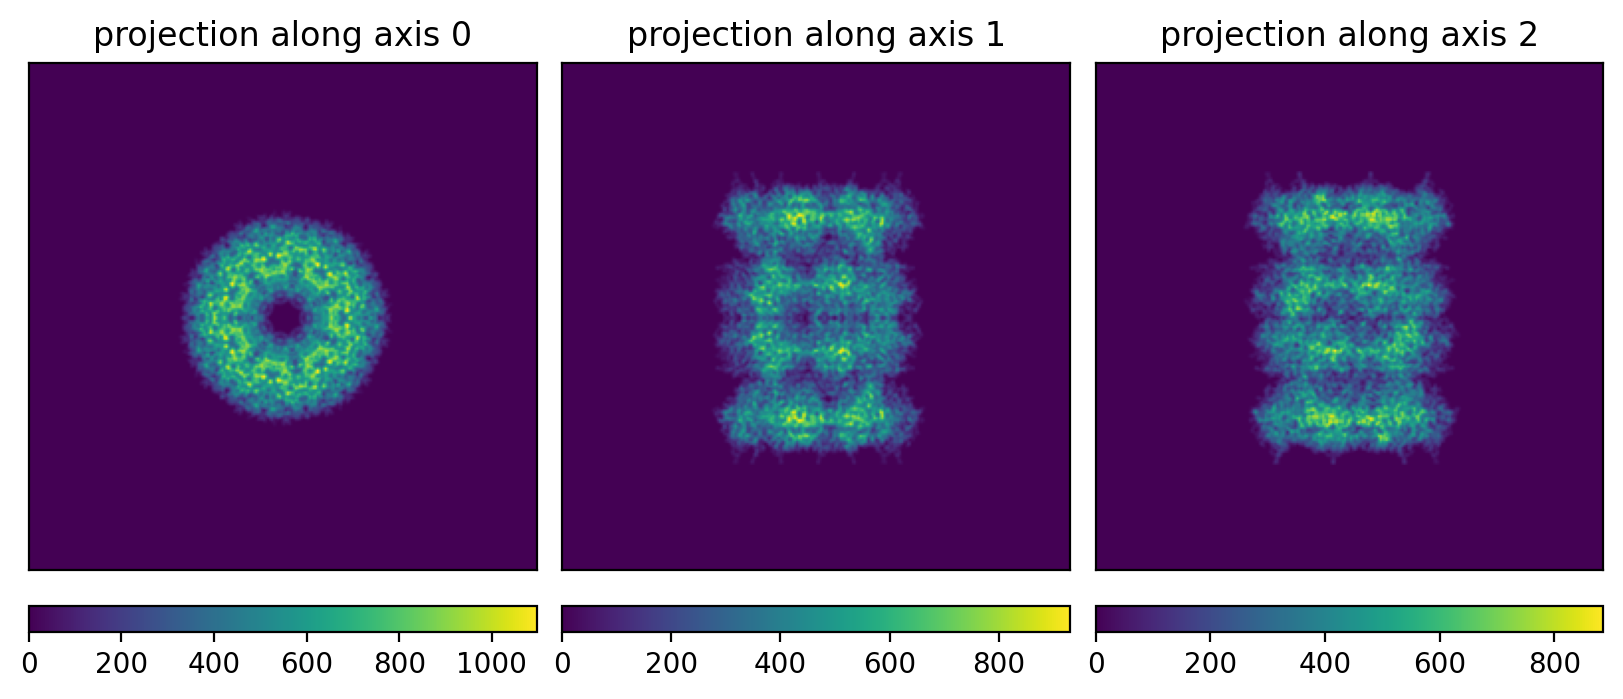

In [9]:
plot3d(V)

## Generate particles
Note: adjust ```coincidence_radius``` to match the contrast of your simulated images to the experiments.

In [10]:
n_particles = 10  # number of particles
device = "cuda:1"  # choose cpu if you run out of cuda memory.

In [11]:
# Use multislice, holography, poisson and random_choice to obtain close to experimental conditions.
scattering_model = "multislice"  # 'multislice', 'firstborn', 'projection', 'ctf'
aberration_model = "holography"  # 'holography' or 'ctf'

noise_model = "poisson"  # 'poisson' or None
# noise_model = None
coincidence_radius = 2.1  # angstrom. Higher value reduces lower spatial frequencies. Set to 0 for default Poisson

ice_model = "iterative"  # 'randomchoice' for fast & inaccurate, 'iterative' for slow & accurate, or None
# ice_model = None

ice_thickness = 0  # angstroms, set to 0 for minimum ice thickness = particle box size

crowd_min_distance = pdb.max_diameter  # angstroms, set to None for no crowding
# crowd_min_distance = None

crowd_max_distance_z = None  # if None, defaults to ice_thickness which would result in too many particles above each other.

# pad_fft = False  # True to avoid edge artifacts when if crowd_min_distance is not None
pad_fft = True

detector_model = None
# detector_model = "perfect"  # 'perfect', 'k3_300kv', 'k3_200kv'

model = ImageGenerator(
    V,
    pixel_size.item(),
    rotations,
    translations_A,
    ctf_params,
    energy_kev,
    dose_per_angstrom,
    ice_model=ice_model,
    ice_thickness=ice_thickness,
    scattering_model=scattering_model,
    aberration_model=aberration_model,
    noise_model=noise_model,
    klim=None,
    flip_curvature=False,
    alpha=alpha,
    crowd_min_distance=crowd_min_distance,
    crowd_max_distance_z=crowd_max_distance_z,
    pad_fft=pad_fft,
    detector_model=detector_model,
    verbose=False,
    coincidence_radius=coincidence_radius,
    num_frames=num_frames,
).to(device)

In [12]:
idx = torch.arange(n_particles)
images = []
batchsize = 5  # set higher or lower for faster/slower generation.
with torch.no_grad():
    for i in track(range(0, n_particles, batchsize), description="Generating images"):
        image = model(idx[i : i + batchsize])
        images.append(image.detach().cpu())

images = torch.concat(images, dim=0)
images.shape

Generating images:   0%|          | 0/2 [00:00<?, ?it/s]

Multislicing:   0%|          | 0/442 [00:00<?, ?it/s]

Applying coincidence loss:   0%|          | 0/53 [00:00<?, ?it/s]

Applying coincidence loss:   0%|          | 0/53 [00:00<?, ?it/s]

Applying coincidence loss:   0%|          | 0/53 [00:00<?, ?it/s]

...

Applying coincidence loss:   0%|          | 0/53 [00:00<?, ?it/s]

Applying coincidence loss:   0%|          | 0/53 [00:00<?, ?it/s]

Applying coincidence loss:   0%|          | 0/53 [00:00<?, ?it/s]

Applying coincidence loss:   0%|          | 0/53 [00:00<?, ?it/s]

torch.Size([10, 256, 256])

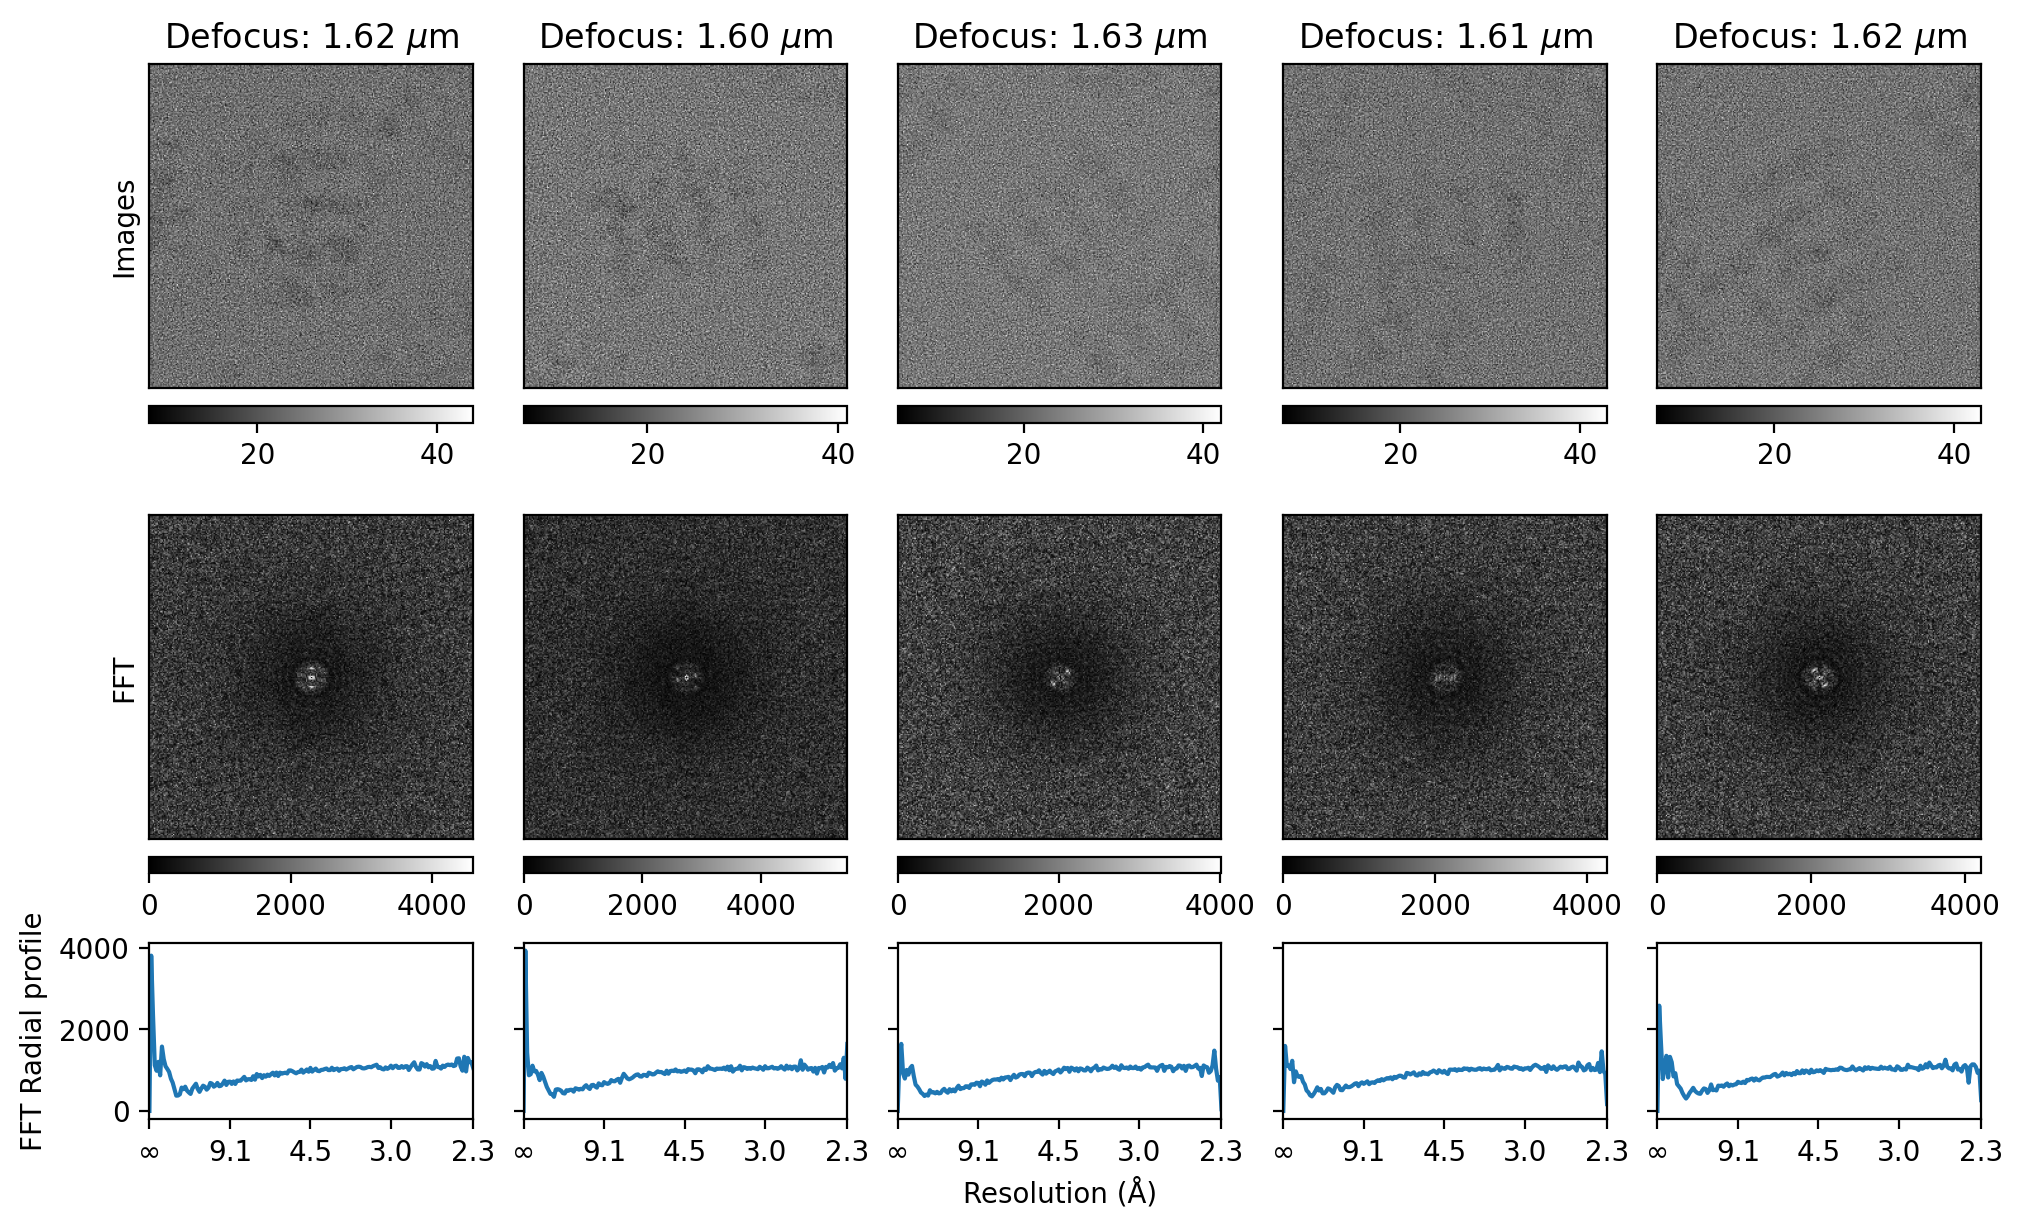

In [13]:
fig, axes = plt.subplots(
    3,
    5,
    dpi=200,
    constrained_layout=True,
    figsize=(10, 6),
    gridspec_kw={"height_ratios": [2, 2, 1]},
)
# after creating the axes, share y across the last row
for ax in axes[2, 1:]:
    ax.sharey(axes[2, 0])
    plt.setp(ax.get_yticklabels(), visible=False)

for i in range(5):
    ax = axes[0, i]
    im = ax.imshow(images[i], cmap="grey")
    ax.set(xticks=[], yticks=[])
    ax.set_title(f"Defocus: {ctf_params['dfu'][i] / 10000:.2f} $\mu$m")
    fig.colorbar(im, ax=ax, location="bottom")

    ax = axes[1, i]
    im = ax.imshow(
        torch.abs(fft2(images[i] - torch.mean(images[i]), shift=True)),
        cmap="grey",
        # vmax=5000,
    )
    ax.set(xticks=[], yticks=[])
    fig.colorbar(im, ax=ax, location="bottom")

    ax = axes[2, i]
    profile = radial_profile_2d(
        torch.abs(fft2(images[i] - torch.mean(images[i]), shift=True))
    )
    n = len(profile)
    ax.plot(profile.numpy() if hasattr(profile, "numpy") else profile)

    # X ticks: 6 ticks from 0 (inf) to n-1 (Nyquist)
    tick_positions = [int(j * (n - 1) / 4) for j in range(5)]
    # Spatial frequency in 1/Å: ranges from 0 to 1/(2*dx)
    # Avoid division by zero at position 0 (inf)
    tick_labels = []
    for pos in tick_positions:
        if pos == 0:
            tick_labels.append("∞")
        else:
            freq = (pos / (n - 1)) * (1 / (2 * pixel_size))  # 1/Å
            resolution = 1 / freq  # Å
            tick_labels.append(f"{resolution:.1f}")

    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels)
    ax.set_xlim(0, n - 1)

axes[0, 0].set(ylabel="Images")
axes[1, 0].set(ylabel="FFT")
axes[2, 0].set(ylabel="FFT Radial profile")
axes[2, 2].set_xlabel("Resolution (Å)")

plt.show()

## Compare with experimental particles (if available)

In [4]:
with mrcfile.open(
    "/scratch/loh/joel/cryosparc_tutorial/CS-cryosparc-tutorial/J35/restack/batch_0_restacked.mrc"
) as mrc:
    exp = torch.as_tensor(mrc.data[...].copy())

In [5]:
# note that experimental images are always flipped.
exp_flipped = -exp

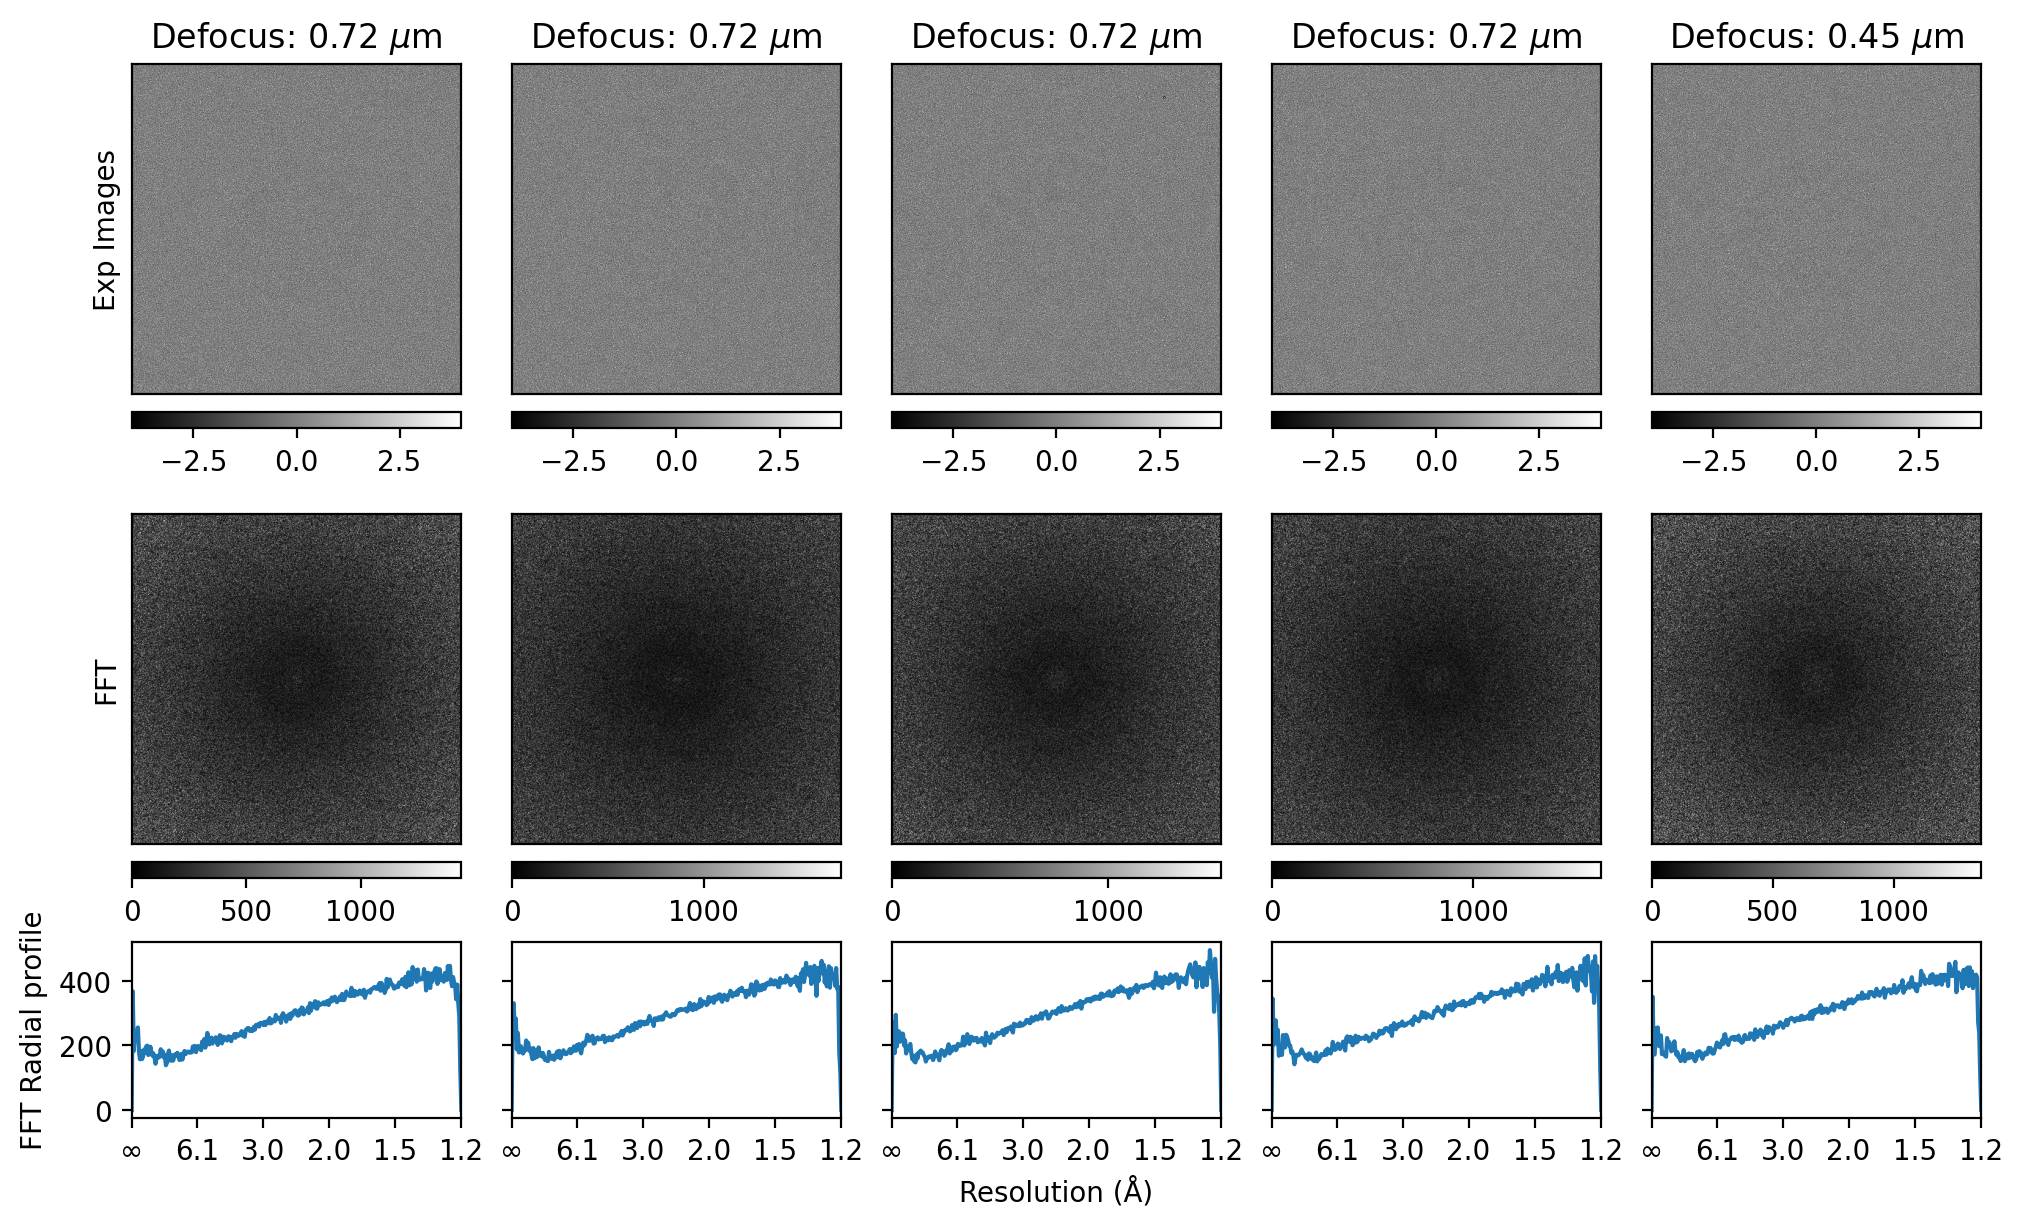

In [11]:
fig, axes = plt.subplots(
    3,
    5,
    dpi=200,
    constrained_layout=True,
    figsize=(10, 6),
    gridspec_kw={"height_ratios": [2, 2, 1]},
)
# after creating the axes, share y across the last row
for ax in axes[2, 1:]:
    ax.sharey(axes[2, 0])
    plt.setp(ax.get_yticklabels(), visible=False)

for i in range(5):
    ax = axes[0, i]
    im = ax.imshow(exp_flipped[i], cmap="grey", vmin=-4, vmax=4)
    ax.set(xticks=[], yticks=[])
    ax.set_title(f"Defocus: {ctf_params['dfu'][i] / 10000:.2f} $\mu$m")
    fig.colorbar(im, ax=ax, location="bottom")

    ax = axes[1, i]
    im = ax.imshow(
        torch.abs(fft2(exp_flipped[i] - torch.mean(exp_flipped[i]), shift=True)),
        cmap="grey",
    )
    ax.set(xticks=[], yticks=[])
    fig.colorbar(im, ax=ax, location="bottom")

    ax = axes[2, i]
    profile = radial_profile_2d(
        torch.abs(fft2(exp_flipped[i] - torch.mean(exp_flipped[i]), shift=True))
    )
    n = len(profile)
    ax.plot(profile.numpy() if hasattr(profile, "numpy") else profile)

    # X ticks: 6 ticks from 0 (inf) to n-1 (Nyquist)
    n_ticks = 7
    tick_positions = [int(j * (n - 1) / (n_ticks - 2)) for j in range(n_ticks - 1)]
    # Spatial frequency in 1/Å: ranges from 0 to 1/(2*dx)
    # Avoid division by zero at position 0 (inf)
    tick_labels = []
    for pos in tick_positions:
        if pos == 0:
            tick_labels.append("∞")
        else:
            freq = (pos / (n - 1)) * (1 / (2 * pixel_size))  # 1/Å
            resolution = 1 / freq  # Å
            tick_labels.append(f"{resolution:.1f}")

    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels)
    ax.set_xlim(0, n - 1)

axes[0, 0].set(ylabel="Exp Images")
axes[1, 0].set(ylabel="FFT")
axes[2, 0].set(ylabel="FFT Radial profile")
axes[2, 2].set_xlabel("Resolution (Å)")

plt.show()